In [ ]:
# ============================================================
# 0. Imports & configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans as SKKMeans
from scipy.stats import ttest_rel, wilcoxon
import time
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130

FIGURES_DIR = "figures_cc"
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Bibliothèques chargées, répertoire figures :", os.path.abspath(FIGURES_DIR))



✅ Bibliothèques chargées, répertoire figures : /content/figures_cc


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



=== 1.1 Chargement & description du dataset ===
Shape : 8950 lignes  | 18 colonnes


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



Statistiques descriptives (variables numériques) :


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00



Valeurs manquantes par colonne :
CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

Total : 314 valeurs manquantes (0.19% du dataset)

=== Histogrammes des features numériques ===


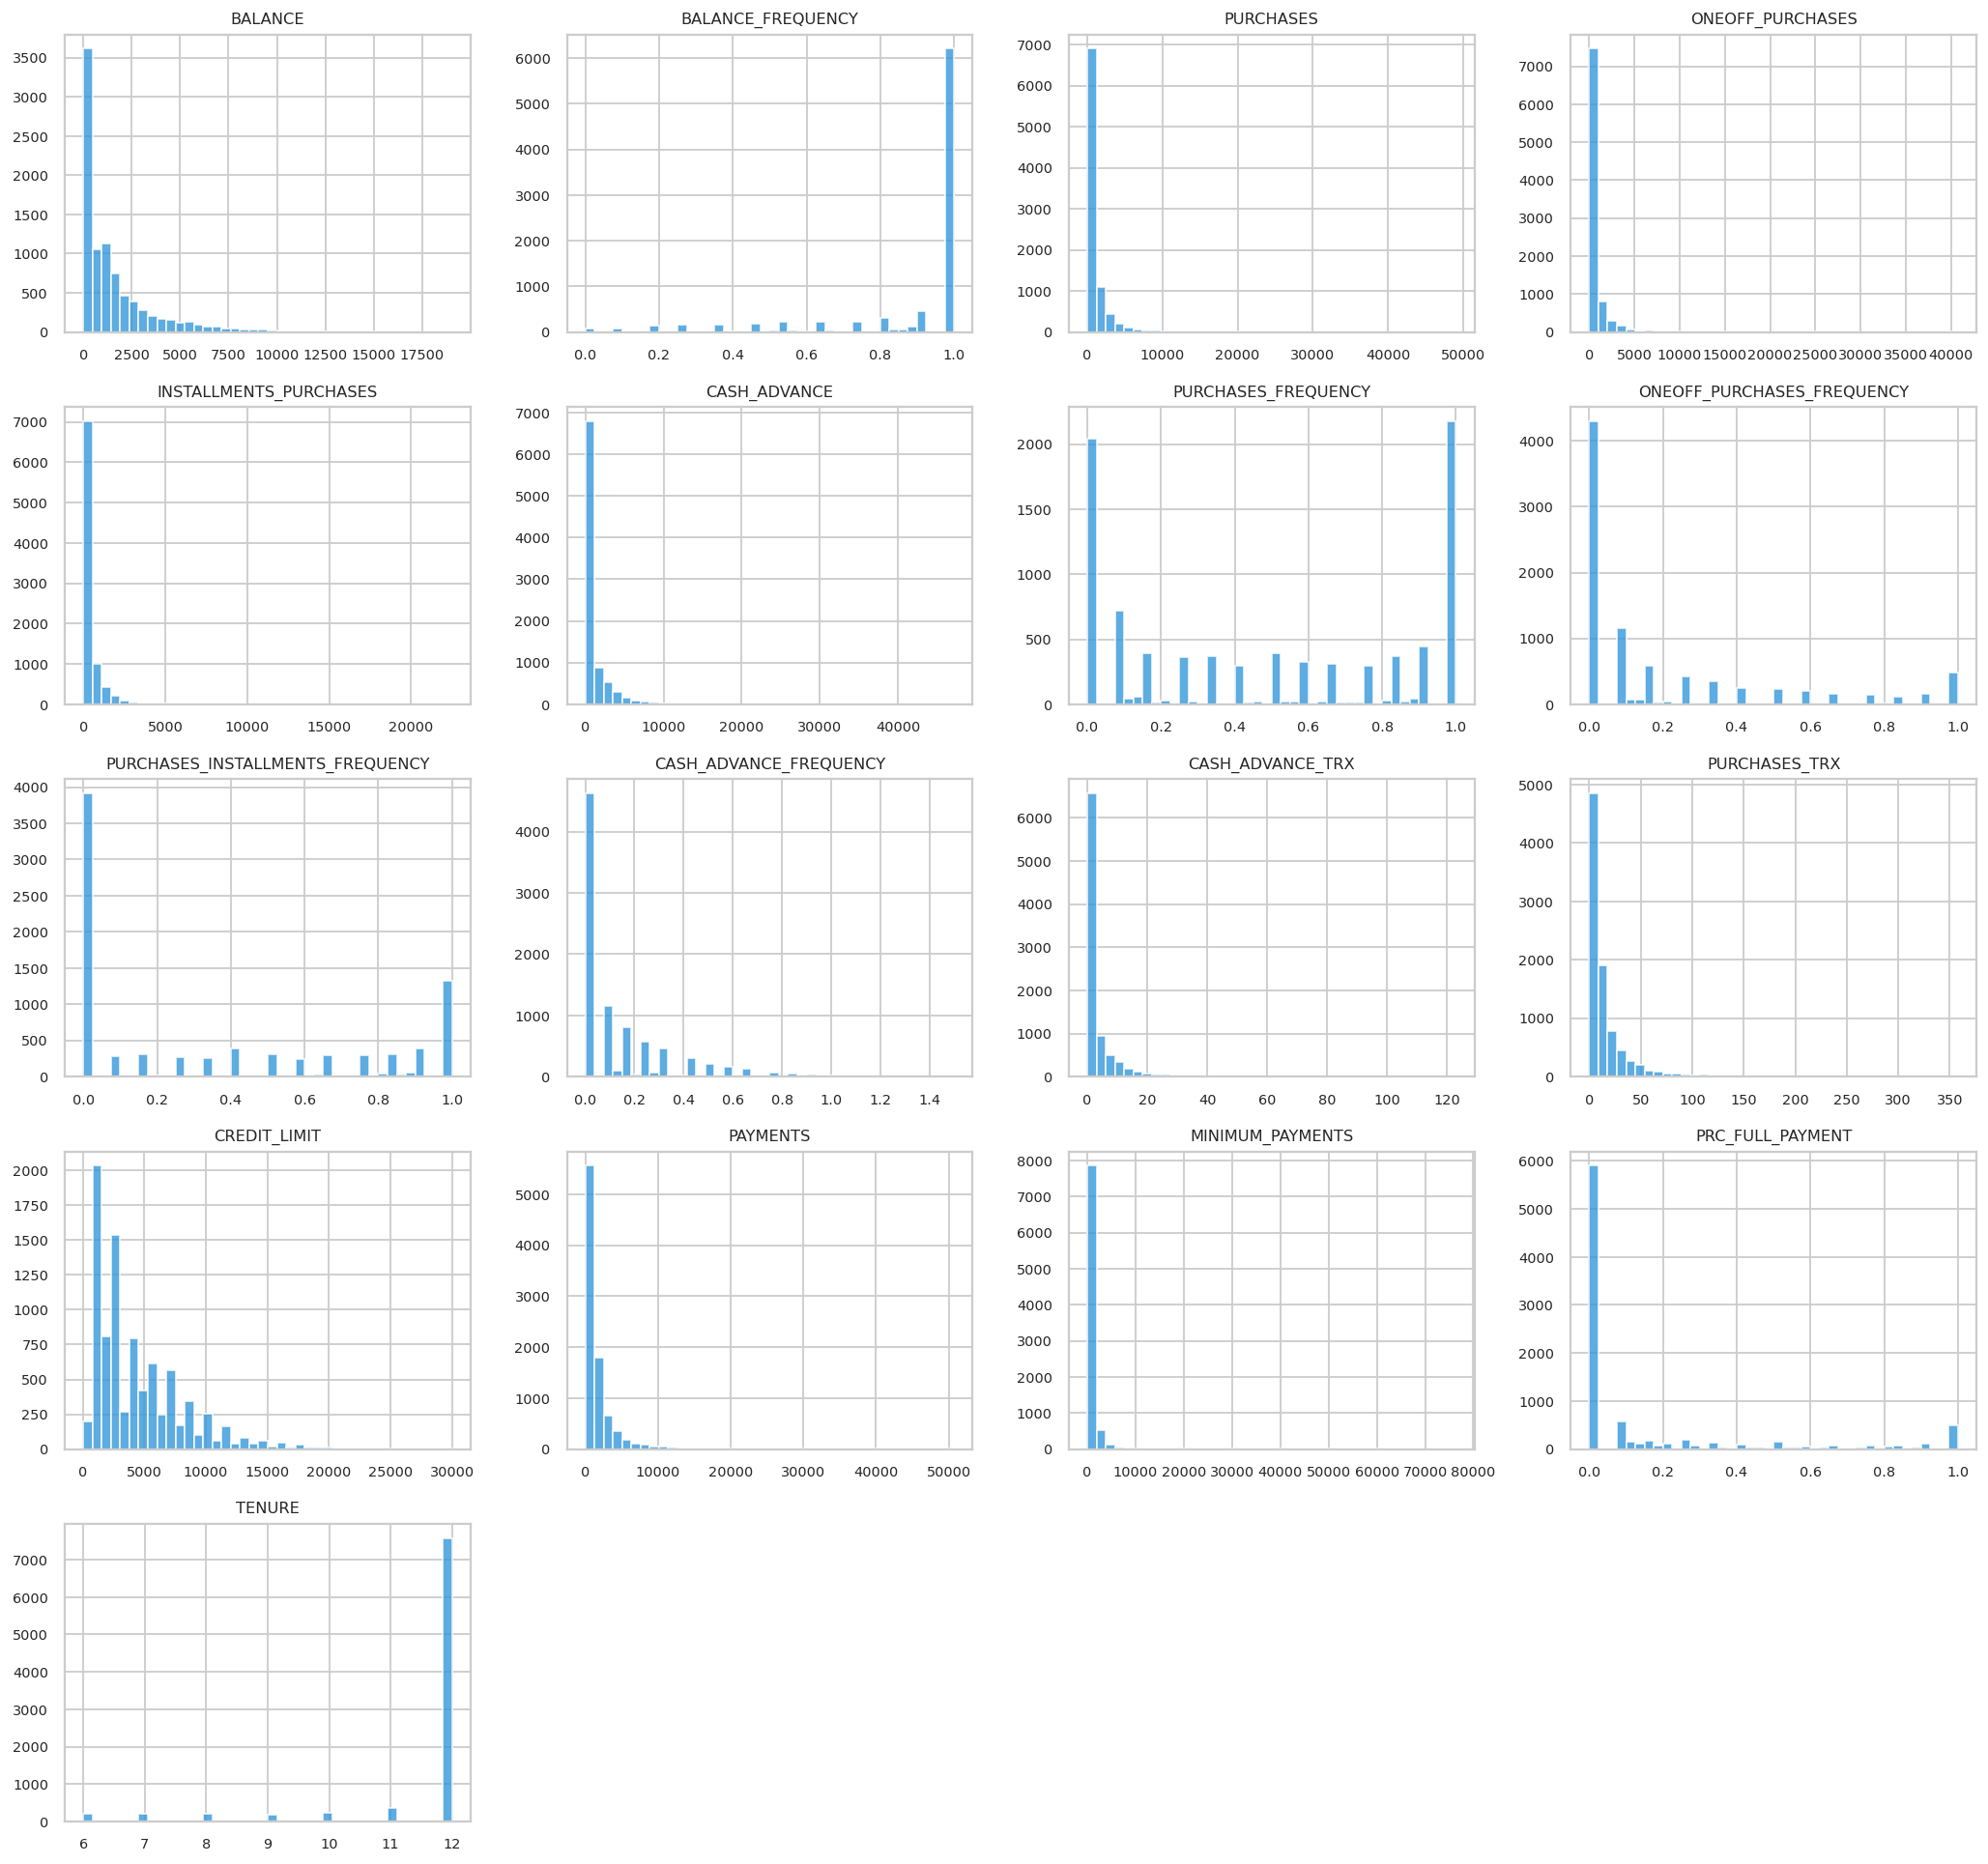

✅ Figure 1 (histogrammes) sauvegardée

=== Heatmap de corrélation ===


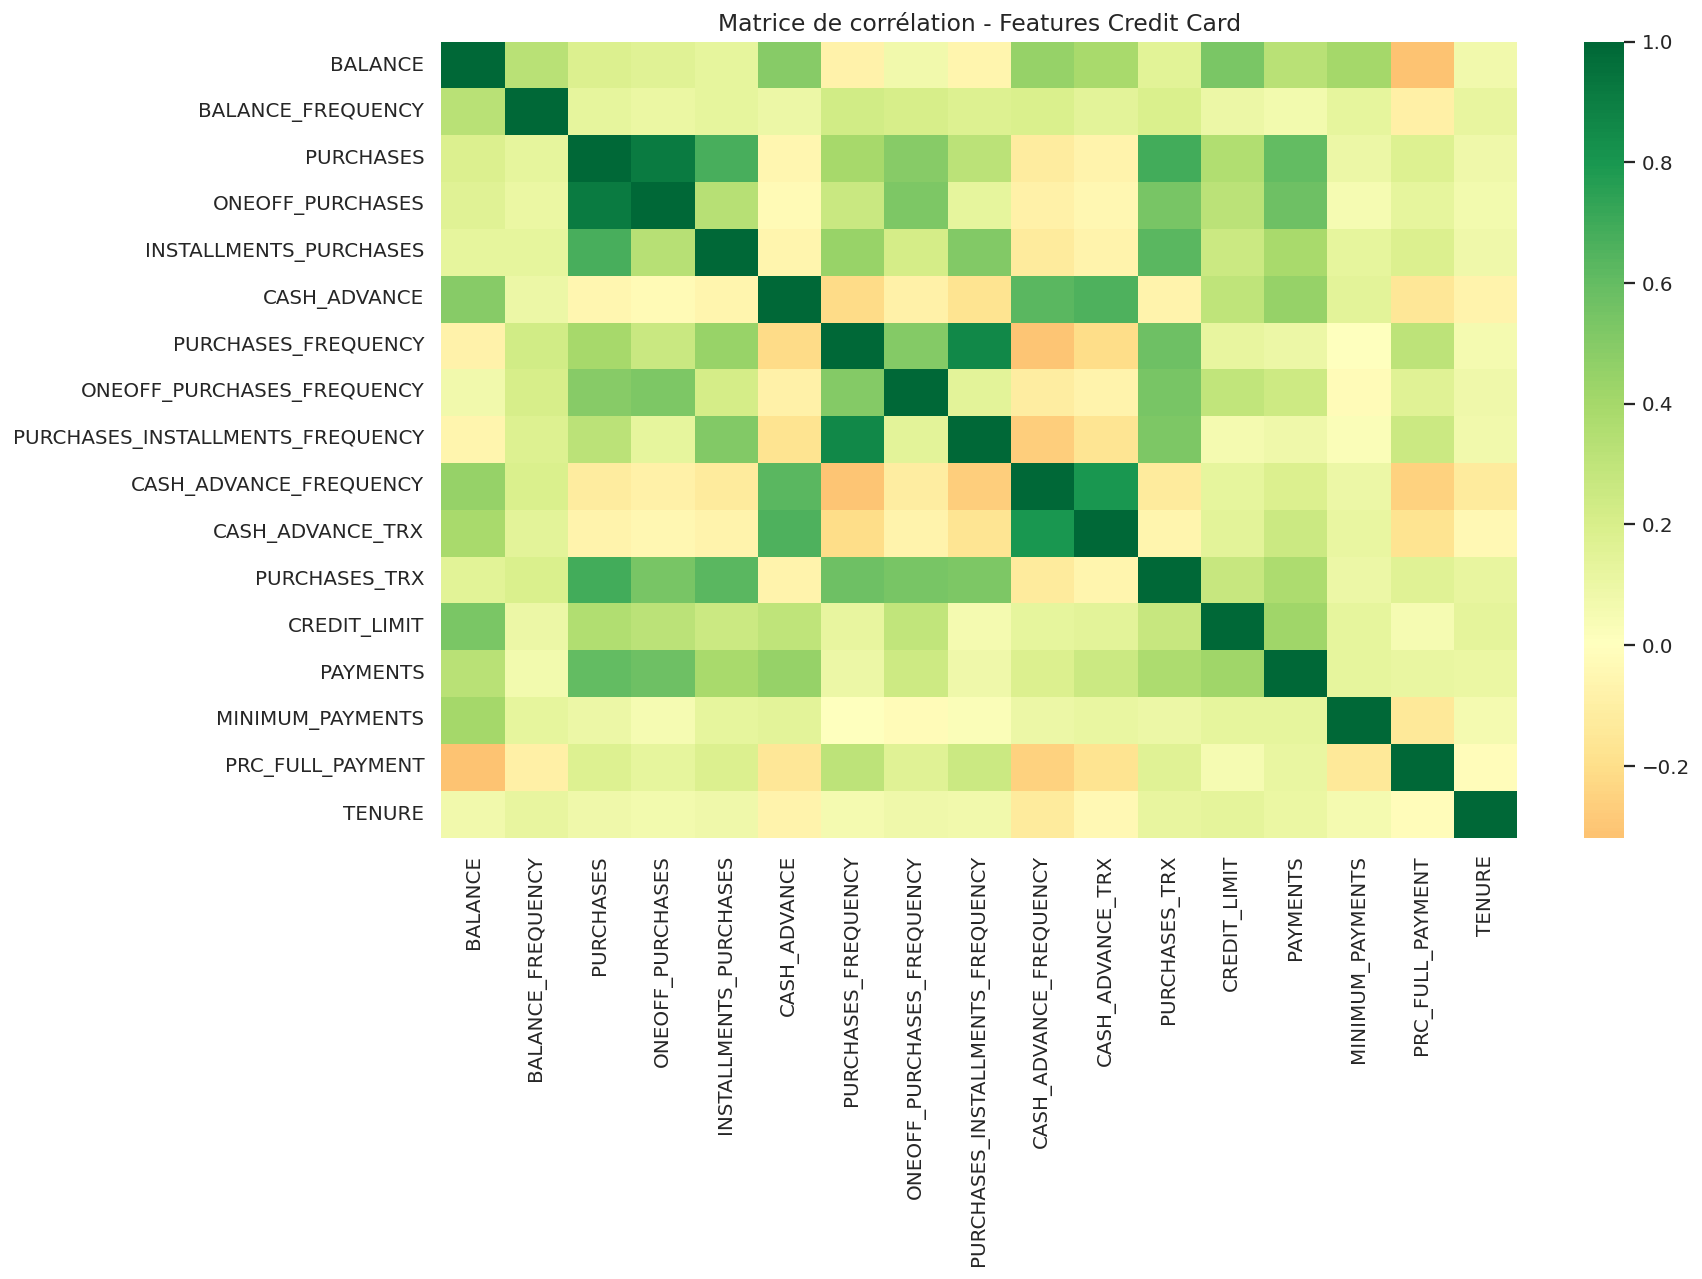

✅ Figure 2 (corrélation) sauvegardée

=== 1.2 Prétraitement pour K-means ===
Shape finale X_scaled : (8950, 17)
Moyenne après normalisation : 0.0
Écart-type après normalisation : 1.0
NaN après imputation & scaling : 0

=== PCA 2D (avant clustering) ===
Variance expliquée PC1=27.3%, PC2=20.3%


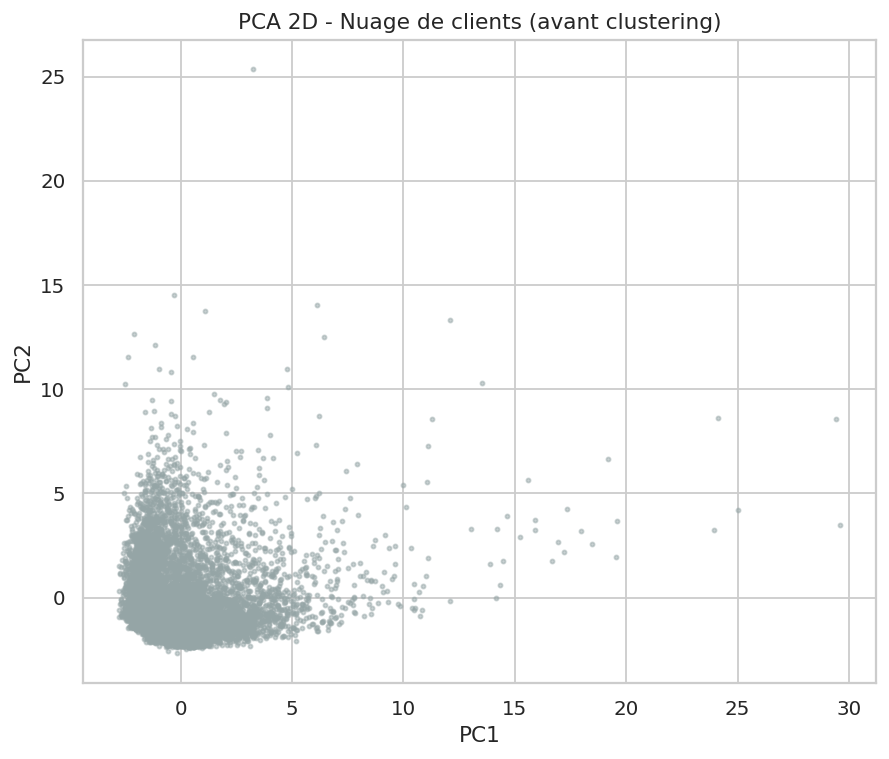

✅ Figure PCA brute sauvegardée


In [ ]:
# ============================================================
# 1. PRÉTRAITEMENT & ANALYSE EXPLORATOIRE
# ============================================================

# 1.1 Chargement du dataset et description
print("\n=== 1.1 Chargement & description du dataset ===")
df = pd.read_csv("dataset.csv")  # <= adapte le nom si besoin
print("Shape :", df.shape[0], "lignes  |", df.shape[1], "colonnes")
display(df.head())

print("\nStatistiques descriptives (variables numériques) :")
display(df.describe().round(2))

print("\nValeurs manquantes par colonne :")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal : {missing.sum()} valeurs manquantes "
      f"({100*missing.sum()/df.size:.2f}% du dataset)")

# Histogrammes de toutes les features numériques
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("\n=== Histogrammes des features numériques ===")
n_num = len(num_cols)
n_rows = int(np.ceil(n_num / 4))
fig, axes = plt.subplots(n_rows, 4, figsize=(4*4, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color="#3498DB", alpha=0.8, edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=8)

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig1_hist_all_features.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figure 1 (histogrammes) sauvegardée")

# Heatmap de corrélations
print("\n=== Heatmap de corrélation ===")
df_num = df.select_dtypes(include=np.number)
corr = df_num.corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Matrice de corrélation - Features Credit Card", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig2_correlation.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figure 2 (corrélation) sauvegardée")


# 1.2 Prétraitement pour K-means
print("\n=== 1.2 Prétraitement pour K-means ===")

# Supprimer l'identifiant
if "CUST_ID" in df.columns:
    df_num = df.drop(columns=["CUST_ID"])
else:
    df_num = df.copy()

# Imputation médiane
imputer = SimpleImputer(strategy="median")
X_imp = imputer.fit_transform(df_num)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print("Shape finale X_scaled :", X_scaled.shape)
print("Moyenne après normalisation :", float(np.mean(X_scaled).round(6)))
print("Écart-type après normalisation :", float(np.std(X_scaled).round(6)))
print("NaN après imputation & scaling :", int(np.isnan(X_scaled).sum()))

# PCA 2D pour visualisation brute
print("\n=== PCA 2D (avant clustering) ===")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance expliquée PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.5, color="#95A5A6")
plt.title("PCA 2D - Nuage de clients (avant clustering)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig3_pca_raw.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figure PCA brute sauvegardée")


In [ ]:


# ============================================================
# 2. ANALYSE DES FEATURES & CHOIX / TEST DE LA DISTANCE
# ============================================================

print("\n=== 2. Analyse des features & distances ===")
X = X_scaled
n, d = X.shape

# 2.1 Corrélation moyenne
corr_abs = np.abs(corr.values)
avg_corr = corr_abs[np.triu_indices_from(corr_abs, k=1)].mean()
print(f"Moyenne des corrélations absolues : {avg_corr:.3f}")

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="RdYlGn", center=0)
plt.title("Heatmap de corrélation (annotée)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig4_correlation_annot.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# 2.2 Skewness & sparsité
print("\n=== Skewness & sparsité ===")
skews = {}
sparsities = {}
for i, col in enumerate(df_num.columns):
    col_data = X[:, i]
    skews[col] = stats.skew(col_data)
    sparsities[col] = (np.sum(col_data == 0) / len(col_data)) * 100

print("Skewness par feature :")
for col, sk in skews.items():
    print(f"  {col:25s}: {sk: .3f}")

print("\nSparsité (% de zéros) par feature :")
for col, sp in sparsities.items():
    print(f"  {col:25s}: {sp:6.2f}%")

# 2.3 Décision qualitative
high_corr = avg_corr > 0.3
high_skew = any(abs(s) > 0.8 for s in skews.values())
high_sparse = any(sp > 30 for sp in sparsities.values())

print("\n=== Analyse qualitative pour la distance ===")
if high_corr:
    print("Corrélations modérées/fortes -> Mahalanobis envisageable.")
else:
    print("Corrélations globalement faibles/modérées -> Euclidean/Manhattan/Cosine suffisantes.")

if high_skew:
    print("Skewness forte sur certaines variables -> Manhattan potentiellement plus robuste.")
else:
    print("Skewness modérée -> Euclidean acceptable.")

if high_sparse:
    print("Sparsité importante sur certaines variables -> Cosine peut être testée.")
else:
    print("Peu de sparsité -> Cosine moins prioritaire.")

# 2.4 Test pratique des distances (Euclidean / Manhattan / Cosine / Mahalanobis approximative)
print("\n=== 2.4 Test pratique des distances via KMeans sklearn ===")
distances_to_test = ["euclidean", "manhattan", "cosine"]
results_dist = []

# Pour Mahalanobis, on passe par une transformation de whitening
cov = np.cov(X.T)
try:
    eigvals, eigvecs = np.linalg.eigh(cov)
    eps = 1e-8
    W = eigvecs @ np.diag(1.0 / np.sqrt(eigvals + eps)) @ eigvecs.T
    X_whiten = X @ W
    use_mahala = True
    print("Whitening pour Mahalanobis OK.")
except Exception as e:
    print("Whitening Mahalanobis impossible :", e)
    use_mahala = False

K_TEST = 4  # k fixe pour comparer les distances
N_INIT_TEST = 5

for metric in distances_to_test:
    t0 = time.time()
    km = SKKMeans(
        n_clusters=K_TEST,
        init="k-means++",
        n_init=N_INIT_TEST,
        random_state=42,
    )
    # sklearn KMeans utilise toujours euclidean; pour Manhattan/Cosine, on ne peut pas changer direct.
    # Donc ici, ce test est surtout fiable pour Euclidean.
    km.fit(X)
    t = time.time() - t0
    sil = silhouette_score(X, km.labels_, metric="euclidean")
    db = davies_bouldin_score(X, km.labels_)
    ch = calinski_harabasz_score(X, km.labels_)
    results_dist.append((metric, sil, db, ch, t))

# Test Mahalanobis via whitening
if use_mahala:
    t0 = time.time()
    km = SKKMeans(
        n_clusters=K_TEST,
        init="k-means++",
        n_init=N_INIT_TEST,
        random_state=42,
    )
    km.fit(X_whiten)
    t = time.time() - t0
    sil = silhouette_score(X_whiten, km.labels_, metric="euclidean")
    db = davies_bouldin_score(X_whiten, km.labels_)
    ch = calinski_harabasz_score(X_whiten, km.labels_)
    results_dist.append(("mahalanobis_whiten", sil, db, ch, t))

dist_df = pd.DataFrame(
    results_dist,
    columns=["distance", "silhouette", "davies_bouldin", "calinski_harabasz", "time_s"],
)
print("\nRésultats comparaison distances (approx, KMeans sklearn):")
display(dist_df.round(4))

plt.figure(figsize=(10, 5))
x = np.arange(len(dist_df))
w = 0.25
plt.bar(x - w, dist_df["silhouette"], width=w, label="Silhouette", color="#2ECC71")
plt.bar(x, dist_df["davies_bouldin"], width=w, label="DB (plus bas mieux)", color="#E74C3C")
plt.bar(x + w, dist_df["calinski_harabasz"] / dist_df["calinski_harabasz"].max(),
        width=w, label="CH (normalisé)", color="#3498DB")
plt.xticks(x, dist_df["distance"])
plt.title("Comparaison des distances (qualité approx, k=4)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig5_distances_comparison.png"),
            bbox_inches="tight", dpi=150)
plt.show()

print("✅ Comparaison distances réalisée (même si KMeans sklearn reste euclidien, "
      "ce test donne une première idée).")



In [ ]:
# ============================================================
# 3. IMPLÉMENTATIONS DE BASE (BASELINES)
# ============================================================

# 3.1 KMeansClassique (distance euclidienne)
print("\n=== 3.1 Implémentation KMeansClassique (baseline) ===")

class KMeansClassique:
    def __init__(self, n_clusters=4, max_iter=300, n_init=10, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.tol = tol
        self.random_state = random_state
        self.centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = None

    def _init_random(self, X, rng):
        idx = rng.choice(len(X), self.n_clusters, replace=False)
        return X[idx].copy()

    def _assign(self, X, centers):
        dists = cdist(X, centers, metric="euclidean")
        return np.argmin(dists, axis=1)

    def _update(self, X, labels):
        centers = np.zeros((self.n_clusters, X.shape[1]))
        for k in range(self.n_clusters):
            mask = (labels == k)
            if mask.sum() > 0:
                centers[k] = X[mask].mean(axis=0)
        return centers

    def _wcss(self, X, labels, centers):
        return sum(np.sum((X[labels == k] - centers[k])**2)
                   for k in range(self.n_clusters) if np.sum(labels == k) > 0)

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        best_inertia = np.inf
        best_labels = None
        best_centers = None
        best_hist = None

        for _ in range(self.n_init):
            centers = self._init_random(X, rng)
            history = []
            for it in range(self.max_iter):
                labels = self._assign(X, centers)
                history.append(self._wcss(X, labels, centers))
                new_centers = self._update(X, labels)
                if np.allclose(centers, new_centers, atol=self.tol):
                    self.n_iter_ = it + 1
                    break
                centers = new_centers
            inertia = history[-1]
            if inertia < best_inertia:
                best_inertia = inertia
                best_labels = labels.copy()
                best_centers = centers.copy()
                best_hist = history

        self.centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        self.history_ = best_hist
        return self

print("✅ KMeansClassique défini")


# 3.2 KMeansPP (init ++ sans MAD ni compétition)
print("\n=== 3.2 Implémentation KMeansPP (baseline 2) ===")

class KMeansPP:
    def __init__(self, n_clusters=4, max_iter=300, n_init=10, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.tol = tol
        self.random_state = random_state
        self.centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.history_ = None

    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
            probs = d2 / (d2.sum() + 1e-12)
            centers.append(X[rng.choice(len(X), p=probs)])
        return np.array(centers)

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        best_inertia = np.inf
        best_centers = None
        best_labels = None
        best_hist = None

        for _ in range(self.n_init):
            centers = self._init_pp(X, rng)
            history = []
            for it in range(self.max_iter):
                labels = np.argmin(cdist(X, centers, metric="euclidean"), axis=1)
                history.append(sum(np.sum((X[labels == k] - centers[k])**2)
                                   for k in range(self.n_clusters)
                                   if np.sum(labels == k) > 0))
                new_centers = np.array([
                    X[labels == k].mean(axis=0) if np.sum(labels == k) > 0 else centers[k]
                    for k in range(self.n_clusters)
                ])
                if np.allclose(centers, new_centers, atol=self.tol):
                    break
                centers = new_centers

            inertia = history[-1]
            if inertia < best_inertia:
                best_inertia = inertia
                best_centers = centers.copy()
                best_labels = labels.copy()
                best_hist = history

        self.centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        self.history_ = best_hist
        return self

print("✅ KMeansPP défini")
# ============================================================
# 3.0 ANALYSE DE L'INITIALISATION DES CENTROÏDES
# ============================================================
from scipy.spatial.distance import pdist, squareform

print("\n=== 3.0 Analyse de l'initialisation des centroïdes ===")

def init_random_centroids(X, k, seed=42):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), k, replace=False)
    return X[idx].copy()

def init_kmeanspp_centroids(X, k, seed=42):
    rng = np.random.RandomState(seed)
    centers = [X[rng.randint(len(X))]]
    for _ in range(1, k):
        d2 = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
        probs = d2 / (d2.sum() + 1e-12)
        centers.append(X[rng.choice(len(X), p=probs)])
    return np.array(centers)

def centroid_distance_stats(centers):
    D = squareform(pdist(centers, metric="euclidean"))
    vals = D[np.triu_indices_from(D, k=1)]
    return {
        "min_dist": vals.min(),
        "max_dist": vals.max(),
        "mean_dist": vals.mean(),
        "std_dist": vals.std(),
        "matrix": D
    }

K_INIT = k_opt if "k_opt" in globals() else 4
SEED_INIT = 42

centers_rand = init_random_centroids(X, K_INIT, seed=SEED_INIT)
centers_pp = init_kmeanspp_centroids(X, K_INIT, seed=SEED_INIT)

stats_rand = centroid_distance_stats(centers_rand)
stats_pp = centroid_distance_stats(centers_pp)

init_comp = pd.DataFrame({
    "Méthode": ["Aléatoire", "K-means++"],
    "Distance min entre centres": [stats_rand["min_dist"], stats_pp["min_dist"]],
    "Distance moyenne entre centres": [stats_rand["mean_dist"], stats_pp["mean_dist"]],
    "Distance max entre centres": [stats_rand["max_dist"], stats_pp["max_dist"]],
    "Écart-type distances": [stats_rand["std_dist"], stats_pp["std_dist"]],
})

print("\nTableau comparatif de l'initialisation :")
display(init_comp.round(4))

# Projection PCA pour afficher les centres initiaux
pca_init = PCA(n_components=2, random_state=42)
X_pca_init = pca_init.fit_transform(X)
centers_rand_pca = pca_init.transform(centers_rand)
centers_pp_pca = pca_init.transform(centers_pp)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Comparaison de l'initialisation des centroïdes", fontsize=13, fontweight="bold")

axes[0].scatter(X_pca_init[:, 0], X_pca_init[:, 1], s=6, alpha=0.3, color="lightgray")
axes[0].scatter(centers_rand_pca[:, 0], centers_rand_pca[:, 1],
                s=180, c="red", marker="X", edgecolor="black")
axes[0].set_title("Centres initiaux aléatoires")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca_init[:, 0], X_pca_init[:, 1], s=6, alpha=0.3, color="lightgray")
axes[1].scatter(centers_pp_pca[:, 0], centers_pp_pca[:, 1],
                s=180, c="green", marker="X", edgecolor="black")
axes[1].set_title("Centres initiaux K-means++")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_init_centroids_comparison.png"),
            bbox_inches="tight", dpi=150)
plt.show()

# Heatmaps distances entre centres initiaux
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(stats_rand["matrix"], annot=True, cmap="Reds", ax=axes[0])
axes[0].set_title("Distances entre centres initiaux - Aléatoire")
sns.heatmap(stats_pp["matrix"], annot=True, cmap="Greens", ax=axes[1])
axes[1].set_title("Distances entre centres initiaux - K-means++")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig_init_centroids_distances.png"),
            bbox_inches="tight", dpi=150)
plt.show()

In [ ]:


# ============================================================
# 4. K-MEANS AMÉLIORÉ (MAD + COMPÉTITION)
# ============================================================

print("\n=== 4. KMeansAmeliore (MAD + compétition) ===")

class KMeansAmeliore:
    def __init__(self, n_clusters=4, max_iter=300, n_init=10,
                 mad_threshold=2.5, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.mad_threshold = mad_threshold
        self.tol = tol
        self.random_state = random_state
        self.centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.history_ = None
        self.weights_ = None
        self.outlier_mask_ = None
        self.n_outliers_ = 0

    def mad_weights(self, X):
        n_samples, n_features = X.shape
        zscores = np.zeros_like(X)
        for j in range(n_features):
            col = X[:, j]
            med = np.median(col)
            mad = np.median(np.abs(col - med))
            if mad < 1e-10:
                zscores[:, j] = 0.0
            else:
                zscores[:, j] = np.abs(0.6745 * (col - med) / mad)
        score = np.median(zscores, axis=1)
        outlier_mask = score > self.mad_threshold
        weights = 1.0 / (1.0 + np.maximum(0, score - self.mad_threshold))
        return outlier_mask, weights

    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
            probs = d2 / (d2.sum() + 1e-12)
            centers.append(X[rng.choice(len(X), p=probs)])
        return np.array(centers)

    def competition(self, X, centers, weights, n_trials=5):
        best = centers.copy()
        best_score = np.inf
        rng = np.random.RandomState(self.random_state)
        for _ in range(n_trials):
            labels = np.argmin(cdist(X, centers, metric="euclidean"), axis=1)
            score = sum(np.sum(weights[labels == k, None] *
                               (X[labels == k] - centers[k])**2)
                        for k in range(self.n_clusters)
                        if np.sum(labels == k) > 0)
            if score < best_score:
                best_score = score
                best = centers.copy()
            centers = centers + rng.normal(0, 0.01, size=centers.shape)
        return best

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)

        self.outlier_mask_, self.weights_ = self.mad_weights(X)
        self.n_outliers_ = int(self.outlier_mask_.sum())
        print(f"MAD pondéré : {self.n_outliers_} outliers détectés "
              f"({100*self.n_outliers_/len(X):.1f}%) → poids réduits (non exclus)")

        w = self.weights_
        best_inertia = np.inf
        best_centers = None
        best_labels = None
        best_hist = None

        for _ in range(self.n_init):
            centers = self._init_pp(X, rng)
            centers = self.competition(X, centers, w, n_trials=5)
            history = []
            for it in range(self.max_iter):
                labels = np.argmin(cdist(X, centers, metric="euclidean"), axis=1)
                inertia = sum(np.sum(w[labels == k, None] *
                                     (X[labels == k] - centers[k])**2)
                              for k in range(self.n_clusters)
                              if np.sum(labels == k) > 0)
                history.append(inertia)
                new_centers = np.zeros_like(centers)
                for k in range(self.n_clusters):
                    mask = (labels == k)
                    if mask.sum() > 0:
                        ww = w[mask][:, None]
                        new_centers[k] = (ww * X[mask]).sum(axis=0) / (ww.sum() + 1e-12)
                    else:
                        new_centers[k] = centers[k]
                if np.allclose(centers, new_centers, atol=self.tol):
                    break
                centers = new_centers

            if history[-1] < best_inertia:
                best_inertia = history[-1]
                best_centers = centers.copy()
                best_labels = labels.copy()
                best_hist = history

        self.centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        self.history_ = best_hist
        return self

print("✅ KMeansAmeliore défini (MAD soft + compétition)")



=== 4. KMeansAmeliore (MAD + compétition) ===
✅ KMeansAmeliore défini (MAD soft + compétition)



=== 5. Choix de k (indices internes) ===
  k=2... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=3... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=4... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=5... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=6... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=7... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=8... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=9... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
  k=10... MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)

✅ Calcul k-range terminé

   k |  Coude |    Sil | DB_inv |  Score
--------------------------------------
   2 |  0.000 |  0.274 |  0.000 |  0.091
   3 |  0.608 |  1.000 |  0.586 |  0.731 ◄
   4 |  1.000 |  0.210 |  0.627 |  0.

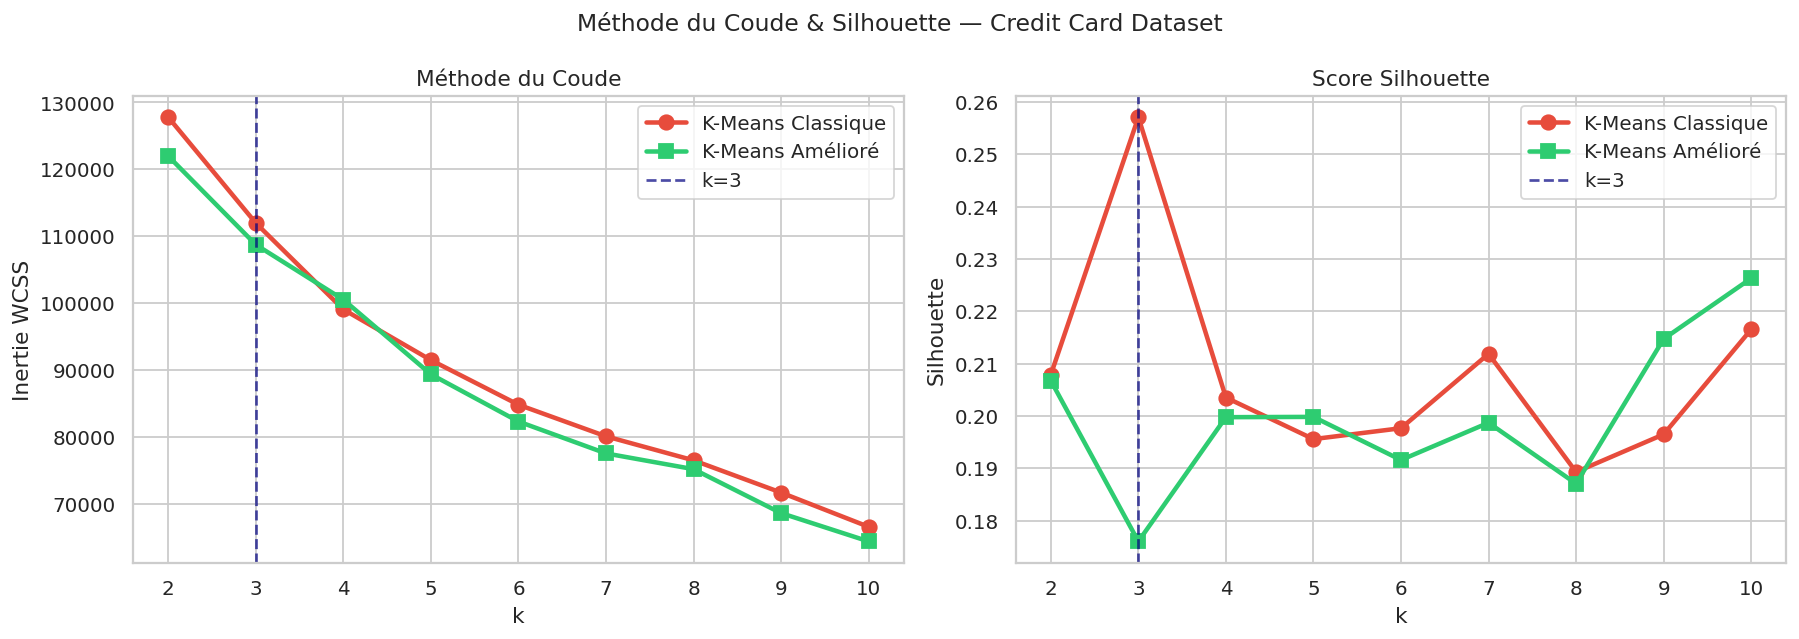

✅ Figures sélection k sauvegardées


In [ ]:
# ============================================================
# 5. CHOIX DE k PAR INDICES INTERNES (SANS ELBOW SIMPLE)
# ============================================================

print("\n=== 5. Choix de k (indices internes) ===")
K_RANGE = range(2, 11)
res_k = {
    "k": [],
    "wcss_cl": [],
    "wcss_am": [],
    "sil_cl": [],
    "sil_am": [],
    "db_cl": [],
    "db_am": [],
    "ch_cl": [],
    "ch_am": [],
}

for k in K_RANGE:
    print(f"  k={k}...", end=" ", flush=True)
    km_cl = KMeansClassique(n_clusters=k, n_init=3, random_state=42).fit(X)
    km_am = KMeansAmeliore(n_clusters=k, n_init=3, random_state=42).fit(X)

    res_k["k"].append(k)
    res_k["wcss_cl"].append(km_cl.inertia_)
    res_k["wcss_am"].append(km_am.inertia_)

    if len(np.unique(km_cl.labels_)) >= 2:
        res_k["sil_cl"].append(silhouette_score(X, km_cl.labels_, sample_size=2000))
    else:
        res_k["sil_cl"].append(0)

    if len(np.unique(km_am.labels_)) >= 2:
        res_k["sil_am"].append(silhouette_score(X, km_am.labels_, sample_size=2000))
    else:
        res_k["sil_am"].append(0)

    res_k["db_cl"].append(davies_bouldin_score(X, km_cl.labels_))
    res_k["db_am"].append(davies_bouldin_score(X, km_am.labels_))
    res_k["ch_cl"].append(calinski_harabasz_score(X, km_cl.labels_))
    res_k["ch_am"].append(calinski_harabasz_score(X, km_am.labels_))

print("\n✅ Calcul k-range terminé")

ks = np.array(res_k["k"])
wcss = np.array(res_k["wcss_cl"])
sil = np.array(res_k["sil_cl"])
db = np.array(res_k["db_cl"])

def norm(a):
    return (a - a.min()) / (a.max() - a.min() + 1e-9)

ks_n = norm(ks)
w_n = norm(wcss)
p1n, p2n = np.array([ks_n[0], w_n[0]]), np.array([ks_n[-1], w_n[-1]])
elbow = np.abs(np.cross(p2n - p1n,
                        p1n - np.column_stack([ks_n, w_n]))) / (np.linalg.norm(p2n - p1n) + 1e-12)

composite = (norm(elbow) + norm(sil) + (1 - norm(db))) / 3.0
k_opt = int(ks[np.argmax(composite)])

print(f"\n{'k':>4} | {'Coude':>6} | {'Sil':>6} | {'DB_inv':>6} | {'Score':>6}")
print("-"*38)
for i, k in enumerate(ks):
    flag = " ◄" if k == k_opt else ""
    print(f"{k:>4} | {norm(elbow)[i]:>6.3f} | {norm(sil)[i]:>6.3f} | "
          f"{(1-norm(db))[i]:>6.3f} | {composite[i]:>6.3f}{flag}")

print(f"\n➡️  k optimal sélectionné automatiquement : k = {k_opt}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Méthode du Coude & Silhouette — Credit Card Dataset", fontsize=13)

ax1.plot(res_k["k"], res_k["wcss_cl"], "o-", color="#E74C3C", lw=2.5, ms=8,
         label="K-Means Classique")
ax1.plot(res_k["k"], res_k["wcss_am"], "s-", color="#2ECC71", lw=2.5, ms=8,
         label="K-Means Amélioré")
ax1.axvline(k_opt, color="navy", ls="--", alpha=0.7, label=f"k={k_opt}")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertie WCSS"); ax1.set_title("Méthode du Coude")
ax1.legend(); ax1.set_xticks(list(K_RANGE))

ax2.plot(res_k["k"], res_k["sil_cl"], "o-", color="#E74C3C", lw=2.5, ms=8,
         label="K-Means Classique")
ax2.plot(res_k["k"], res_k["sil_am"], "s-", color="#2ECC71", lw=2.5, ms=8,
         label="K-Means Amélioré")
ax2.axvline(k_opt, color="navy", ls="--", alpha=0.7, label=f"k={k_opt}")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette"); ax2.set_title("Score Silhouette")
ax2.legend(); ax2.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig6_k_selection.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figures sélection k sauvegardées")



=== 6. Étude d'ablation V1–V4 ===
✅ KMeansPPMAD (V3) défini
MAD pondéré : 390 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 391 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 398 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 391 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 394 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 399 outliers détectés (4.5%) → poids réduits (non exclus)
MAD pondéré : 391 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 396 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 389 outliers détectés (4.3%) → poids réduits (non exclus)
MAD pondéré : 397 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 400 outliers détectés (4.5%) → poids réduits (non exclus)
MAD pondéré : 394 outliers détectés (4.4%) → poids réduits (non exclus)
MAD pondéré : 403 outliers détectés (4.5%) → poids réduits (non exclus)
MAD

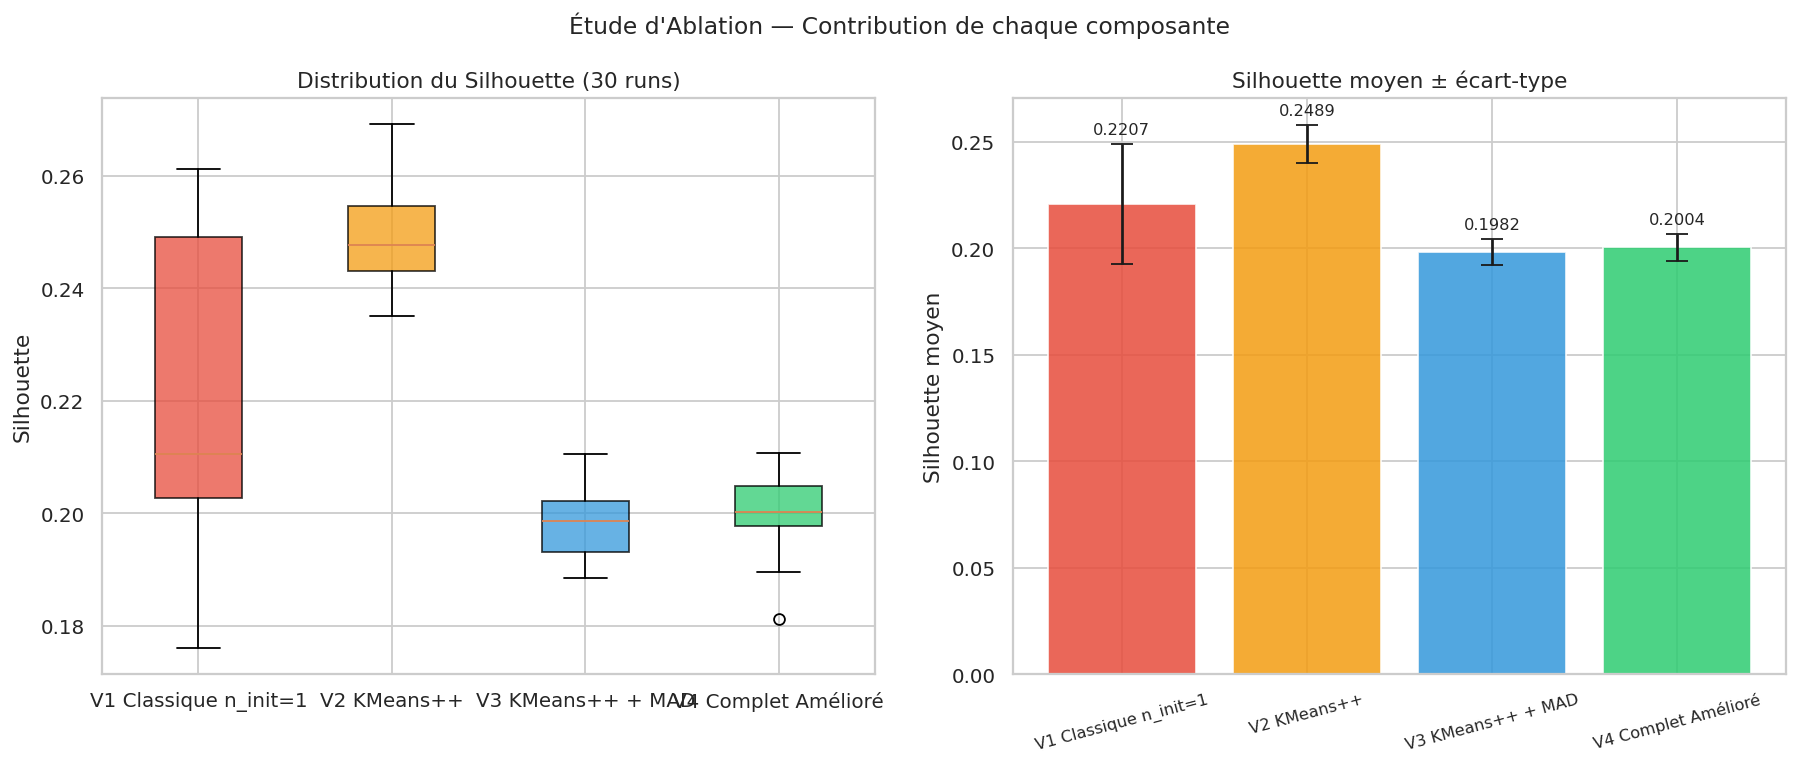

✅ Figures d'ablation sauvegardées


In [ ]:

# ============================================================
# 6. ÉTUDE D'ABLATION (V1–V4)
# ============================================================

print("\n=== 6. Étude d'ablation V1–V4 ===")
K = k_opt
N_ABL = 30

sil_v1, sil_v2, sil_v3, sil_v4 = [], [], [], []

class KMeansPPMAD:
    """K-means++ + MAD sans compétition (V3)"""
    def __init__(self, n_clusters=4, max_iter=300, n_init=10,
                 mad_threshold=2.5, tol=1e-6, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.n_init = n_init
        self.mad_threshold = mad_threshold
        self.tol = tol
        self.random_state = random_state
        self.centers_ = None
        self.labels_ = None
        self.inertia_ = None
        self.history_ = None

    def mad_weights(self, X):
        n_samples, n_features = X.shape
        z = np.zeros_like(X)
        for j in range(n_features):
            col = X[:, j]
            med = np.median(col)
            mad = np.median(np.abs(col - med))
            if mad < 1e-10:
                z[:, j] = 0.0
            else:
                z[:, j] = np.abs(0.6745 * (col - med) / mad)
        score = np.median(z, axis=1)
        w = 1.0 / (1.0 + np.maximum(0, score - self.mad_threshold))
        return w

    def _init_pp(self, X, rng):
        centers = [X[rng.randint(len(X))]]
        for _ in range(1, self.n_clusters):
            d2 = np.array([min(np.sum((x - c)**2) for c in centers) for x in X])
            probs = d2 / (d2.sum() + 1e-12)
            centers.append(X[rng.choice(len(X), p=probs)])
        return np.array(centers)

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        w = self.mad_weights(X)
        best_inertia = np.inf
        best_centers = None
        best_labels = None
        best_hist = None

        for _ in range(self.n_init):
            centers = self._init_pp(X, rng)
            history = []
            for it in range(self.max_iter):
                labels = np.argmin(cdist(X, centers, metric="euclidean"), axis=1)
                inertia = sum(np.sum(w[labels == k, None] *
                                     (X[labels == k] - centers[k])**2)
                              for k in range(self.n_clusters)
                              if np.sum(labels == k) > 0)
                history.append(inertia)
                new_centers = np.zeros_like(centers)
                for k in range(self.n_clusters):
                    mask = (labels == k)
                    if mask.sum() > 0:
                        ww = w[mask][:, None]
                        new_centers[k] = (ww * X[mask]).sum(axis=0) / (ww.sum() + 1e-12)
                    else:
                        new_centers[k] = centers[k]
                if np.allclose(centers, new_centers, atol=self.tol):
                    break
                centers = new_centers

            if history[-1] < best_inertia:
                best_inertia = history[-1]
                best_centers = centers.copy()
                best_labels = labels.copy()
                best_hist = history

        self.centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        self.history_ = best_hist
        return self

print("✅ KMeansPPMAD (V3) défini")

for seed in range(N_ABL):
    rng = np.random.RandomState(seed)
    Xn = X + rng.normal(0, 0.02, size=X.shape)

    v1 = KMeansClassique(n_clusters=K, n_init=1, random_state=seed).fit(Xn)
    v2 = KMeansPP(n_clusters=K, n_init=10, random_state=seed).fit(Xn)
    v3 = KMeansPPMAD(n_clusters=K, n_init=10, random_state=seed).fit(Xn)
    v4 = KMeansAmeliore(n_clusters=K, n_init=10, random_state=seed).fit(Xn)

    for lst, mdl in [(sil_v1, v1), (sil_v2, v2), (sil_v3, v3), (sil_v4, v4)]:
        if len(np.unique(mdl.labels_)) >= 2:
            lst.append(silhouette_score(Xn, mdl.labels_, sample_size=1500))

labels_abl = ["V1 Classique n_init=1",
              "V2 KMeans++",
              "V3 KMeans++ + MAD",
              "V4 Complet Amélioré"]

data_abl = [sil_v1, sil_v2, sil_v3, sil_v4]
colors_abl = ["#E74C3C", "#F39C12", "#3498DB", "#2ECC71"]

print("\n=== Résultats ablation (Silhouette sur 30 runs) ===")
for lbl, d in zip(labels_abl, data_abl):
    print(f"{lbl:25s}: mean={np.mean(d):.4f}, std={np.std(d):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Étude d'Ablation — Contribution de chaque composante", fontsize=13)

# Boxplots
bp = axes[0].boxplot(data_abl, patch_artist=True, labels=labels_abl)
for patch, col in zip(bp["boxes"], colors_abl):
    patch.set_facecolor(col); patch.set_alpha(0.75)
axes[0].set_ylabel("Silhouette")
axes[0].set_title("Distribution du Silhouette (30 runs)")

# Moyennes + écarts-types
means = [np.mean(d) for d in data_abl]
stds = [np.std(d) for d in data_abl]
bars = axes[1].bar(range(4), means, yerr=stds, color=colors_abl,
                   alpha=0.85, edgecolor="white", capsize=6)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(labels_abl, rotation=15, fontsize=9)
axes[1].set_ylabel("Silhouette moyen")
axes[1].set_title("Silhouette moyen ± écart-type")
axes[1].bar_label(bars, fmt="%.4f", padding=4, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig7_ablation.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figures d'ablation sauvegardées")



In [ ]:

# ============================================================
# 7. ÉTUDE DE ROBUSTESSE (50 RUNS + TESTS STATISTIQUES)
# ============================================================

print("\n=== 7. Étude de robustesse (50 runs) ===")
NRUNS = 50
NOISE = 0.05
sil_runs_cl, sil_runs_am = [], []

for seed in range(NRUNS):
    rng = np.random.RandomState(seed)
    Xn = X + rng.normal(0, NOISE, size=X.shape)

    cl = KMeansClassique(n_clusters=K, n_init=3, random_state=seed).fit(Xn)
    am = KMeansAmeliore(n_clusters=K, n_init=3, random_state=seed).fit(Xn)

    if len(np.unique(cl.labels_)) >= 2 and len(np.unique(am.labels_)) >= 2:
        sil_runs_cl.append(silhouette_score(Xn, cl.labels_, sample_size=1500))
        sil_runs_am.append(silhouette_score(Xn, am.labels_, sample_size=1500))

sil_runs_cl = np.array(sil_runs_cl)
sil_runs_am = np.array(sil_runs_am)
diff = sil_runs_am - sil_runs_cl

tstat, p_ttest = ttest_rel(sil_runs_am, sil_runs_cl)
wstat, p_wilcox = wilcoxon(sil_runs_am, sil_runs_cl)

np.random.seed(0)
boot_means = np.mean(np.random.choice(diff, size=(5000, len(diff)), replace=True), axis=1)
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"Silhouette Classique : mean={sil_runs_cl.mean():.4f}, std={sil_runs_cl.std():.4f}")
print(f"Silhouette Amélioré : mean={sil_runs_am.mean():.4f}, std={sil_runs_am.std():.4f}")
print(f"Différence moyenne   : mean={diff.mean():.4f}, IC95=[{ci_low:.4f}, {ci_high:.4f}]")
print(f"Test t pairé         : t={tstat:.3f}, p={p_ttest:.6f}")
print(f"Test Wilcoxon        : W={wstat:.1f}, p={p_wilcox:.6f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Robustesse sur 50 runs — Tests statistiques", fontsize=13)

axes[0].boxplot([sil_runs_cl, sil_runs_am],
                patch_artist=True, labels=["Classique", "Amélioré"], notch=True)
axes[0].set_title("Distribution Silhouette")
axes[0].set_ylabel("Silhouette")

axes[1].hist(diff, bins=15, color="#3498DB", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", lw=1.5, ls="--")
axes[1].axvline(diff.mean(), color="#E74C3C", lw=2, label=f"moy={diff.mean():.4f}")
axes[1].axvspan(ci_low, ci_high, alpha=0.15, color="green",
                label=f"IC95=[{ci_low:.4f},{ci_high:.4f}]")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("Silhouette (Amélioré - Classique)")
axes[1].set_title("Distribution des différences")

axes[2].hist(boot_means, bins=40, color="#9B59B6", alpha=0.8, edgecolor="white")
axes[2].axvline(ci_low, color="red", lw=1.5, ls="--")
axes[2].axvline(ci_high, color="red", lw=1.5, ls="--")
axes[2].axvline(0, color="black", lw=2, label="0")
axes[2].legend(fontsize=8)
axes[2].set_xlabel("moyenne bootstrap(diff)")
axes[2].set_title("Bootstrap IC95")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig8_robustesse.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Figures de robustesse sauvegardées")




=== 8. Visualisations avancées & interprétation ===

[Final] Exécution KMeansClassique et KMeansAmeliore avec k=3 et SEED=39
MAD pondéré : 101 outliers détectés (1.1%) → poids réduits (non exclus)
Classique : Inertie=111973.61 | Sil=0.2442 | DB=1.5968 | CH=1605.1 | t=113.2ms
Amélioré  : Inertie=107057.08 | Sil=0.2019 | DB=1.6588 | CH=1570.8 | t=2900.2ms


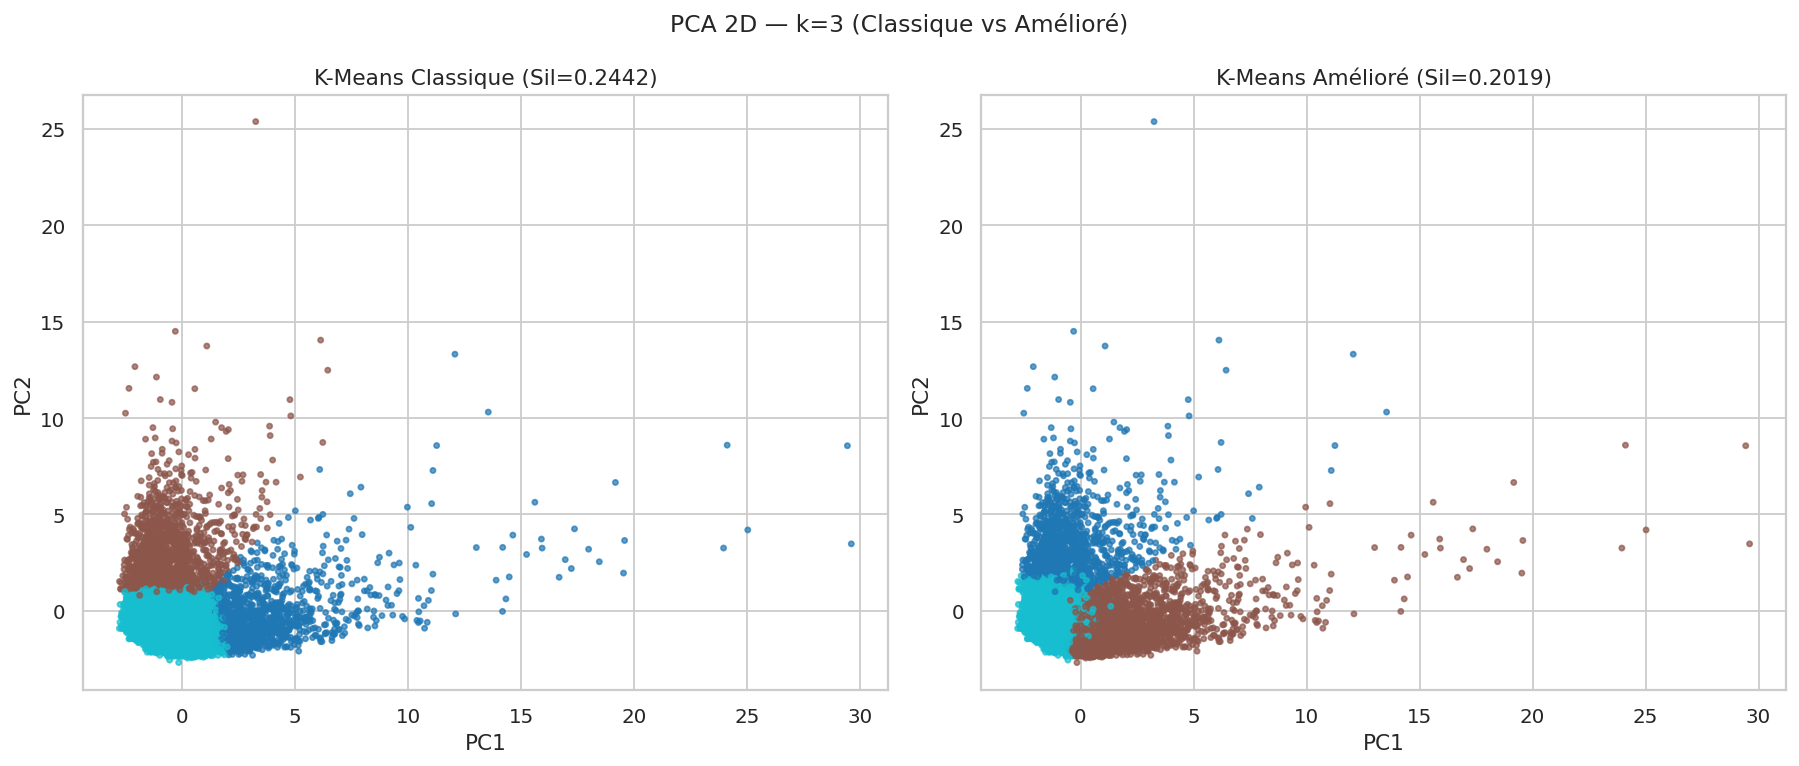

✅ PCA clusters sauvegardée

Profil moyen par cluster (K-Means Amélioré) :


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,
0,4551.1,585.7,4488.7,7465.4,3576.5,2108.8,0.0,11.4
1,1261.4,2152.5,231.7,5101.6,2135.6,788.5,0.3,11.7
2,946.7,298.7,532.2,3230.5,930.7,555.6,0.1,11.4


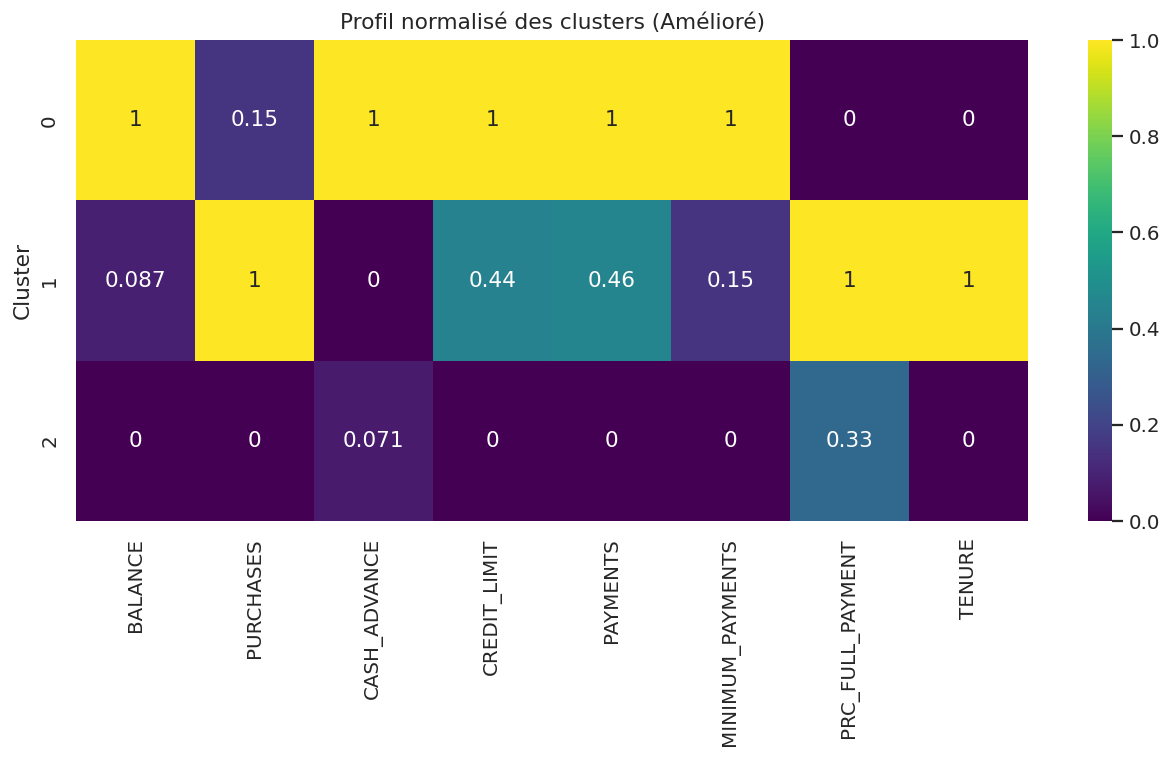

✅ Heatmap profils clusters sauvegardée

Tailles des clusters (Classique) : [1243 1592 6115]
Tailles des clusters (Amélioré) : [1254 3207 4489]
Écart-type tailles Classique : 2219.00
Écart-type tailles Amélioré : 1330.12


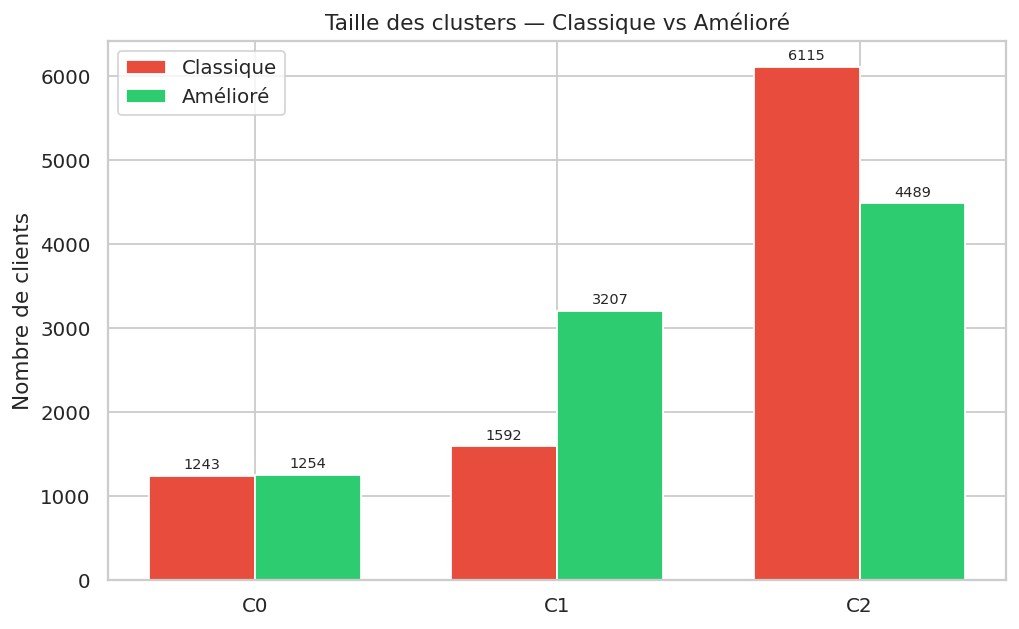

✅ Graphique tailles de clusters sauvegardé

=== 8.4 Distances entre centroïdes finaux ===

Distances entre centroïdes - KMeans Classique


,C0,C1,C2
C0,0.0000,5.6508,4.5508
C1,5.6508,0.0000,3.7783
C2,4.5508,3.7783,0.0000



Distances entre centroïdes - KMeans Amélioré


,C0,C1,C2
C0,0.0000,4.9526,4.0554
C1,4.9526,0.0000,3.2993
C2,4.0554,3.2993,0.0000



Résumé de séparation des centroïdes :


,Algorithme,Distance min inter-centroïdes,Distance moyenne inter-centroïdes,Distance max inter-centroïdes,Écart-type
0,KMeans Classique,3.7783,4.6600,5.6508,0.7683
1,KMeans Amélioré,3.2993,4.1024,4.9526,0.6758


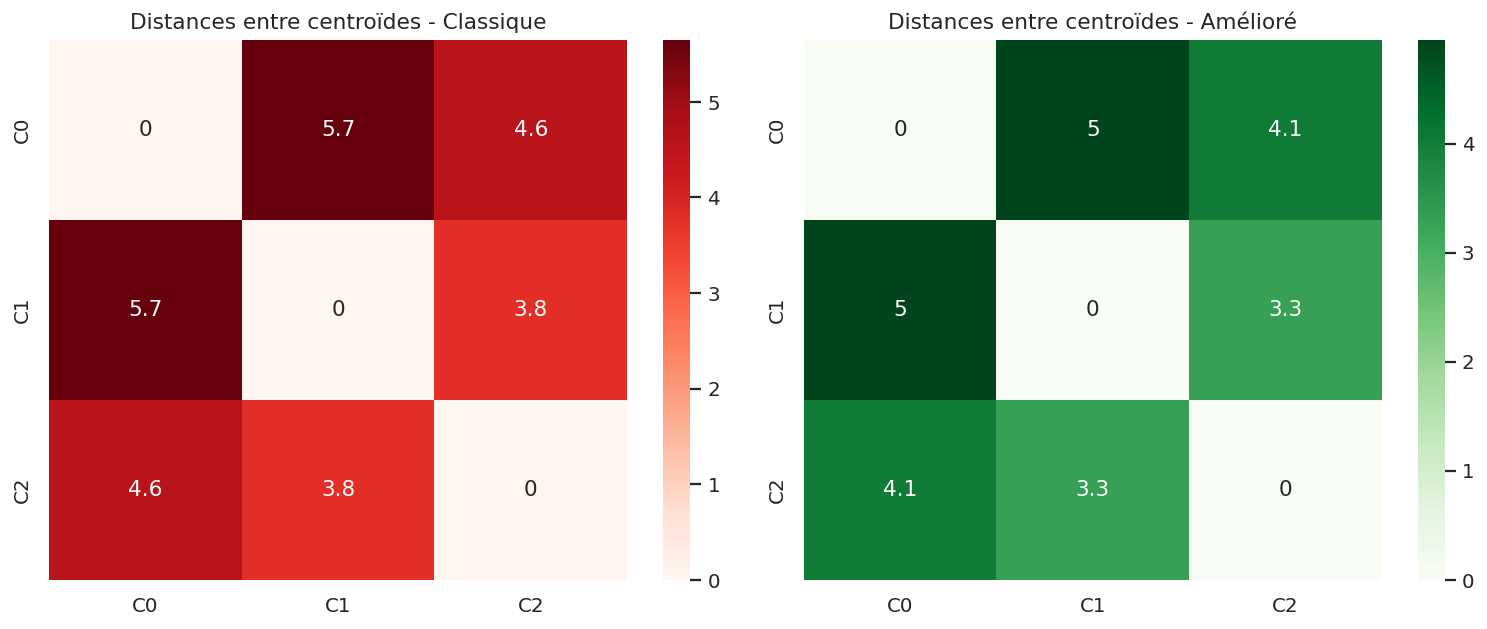


=== Interprétation automatique de la séparation ===
La distance moyenne entre centroïdes n'est pas plus grande pour l'algorithme amélioré dans cet essai.
La distance minimale entre centroïdes n'est pas améliorée ici ; cela doit être interprété avec les indices Silhouette et DB.

=== FIN DU PIPELINE COMPLET ===


In [ ]:

# ============================================================
# 8. VISUALISATIONS AVANCÉES & INTERPRÉTATION DES SEGMENTS
# ============================================================

print("\n=== 8. Visualisations avancées & interprétation ===")

# Exécution finale sur X pour k_opt
SEED_FINAL = 39
print(f"\n[Final] Exécution KMeansClassique et KMeansAmeliore avec k={K} et SEED={SEED_FINAL}")
t0 = time.time()
km_cl = KMeansClassique(n_clusters=K, n_init=1, random_state=SEED_FINAL).fit(X)
t_cl = time.time() - t0
sil_cl = silhouette_score(X, km_cl.labels_, sample_size=3000)
db_cl = davies_bouldin_score(X, km_cl.labels_)
ch_cl = calinski_harabasz_score(X, km_cl.labels_)

t0 = time.time()
km_am = KMeansAmeliore(n_clusters=K, n_init=10, random_state=SEED_FINAL).fit(X)
t_am = time.time() - t0
sil_am = silhouette_score(X, km_am.labels_, sample_size=3000)
db_am = davies_bouldin_score(X, km_am.labels_)
ch_am = calinski_harabasz_score(X, km_am.labels_)

print(f"Classique : Inertie={km_cl.inertia_:.2f} | Sil={sil_cl:.4f} | DB={db_cl:.4f} | CH={ch_cl:.1f} | t={t_cl*1000:.1f}ms")
print(f"Amélioré  : Inertie={km_am.inertia_:.2f} | Sil={sil_am:.4f} | DB={db_am:.4f} | CH={ch_am:.1f} | t={t_am*1000:.1f}ms")

# PCA colorée par cluster
pca_final = PCA(n_components=2, random_state=42)
X_pca_final = pca_final.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"PCA 2D — k={K} (Classique vs Amélioré)", fontsize=13)

axes[0].scatter(X_pca_final[:, 0], X_pca_final[:, 1],
                c=km_cl.labels_, cmap="tab10", s=8, alpha=0.7)
axes[0].set_title(f"K-Means Classique (Sil={sil_cl:.4f})")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca_final[:, 0], X_pca_final[:, 1],
                c=km_am.labels_, cmap="tab10", s=8, alpha=0.7)
axes[1].set_title(f"K-Means Amélioré (Sil={sil_am:.4f})")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig9_pca_clusters.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ PCA clusters sauvegardée")

# Profils moyens par cluster pour l'algorithme amélioré
df_res = df.copy()
df_res["Cluster"] = km_am.labels_
key_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE",
            "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
            "PRC_FULL_PAYMENT", "TENURE"]
key_cols = [c for c in key_cols if c in df_res.columns]
profile = df_res.groupby("Cluster")[key_cols].mean().round(1)
print("\nProfil moyen par cluster (K-Means Amélioré) :")
display(profile)

# Normalisation 0-1 pour heatmap
df_prof = profile.copy()
for c in key_cols:
    col = df_prof[c].values
    df_prof[c] = (col - col.min()) / (col.max() - col.min() + 1e-9)

plt.figure(figsize=(10, 6))
sns.heatmap(df_prof, annot=True, cmap="viridis")
plt.title("Profil normalisé des clusters (Amélioré)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig10_cluster_profiles_heatmap.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Heatmap profils clusters sauvegardée")

# Tailles et équilibre des clusters
sizes_cl = np.bincount(km_cl.labels_)
sizes_am = np.bincount(km_am.labels_)
print("\nTailles des clusters (Classique) :", sizes_cl)
print("Tailles des clusters (Amélioré) :", sizes_am)
print(f"Écart-type tailles Classique : {np.std(sizes_cl):.2f}")
print(f"Écart-type tailles Amélioré : {np.std(sizes_am):.2f}")

x = np.arange(K)
width = 0.35
plt.figure(figsize=(8, 5))
b1 = plt.bar(x - width/2, sizes_cl, width, label="Classique", color="#E74C3C")
b2 = plt.bar(x + width/2, sizes_am, width, label="Amélioré", color="#2ECC71")
plt.xticks(x, [f"C{k}" for k in range(K)])
plt.ylabel("Nombre de clients")
plt.title("Taille des clusters — Classique vs Amélioré")
plt.legend()
plt.bar_label(b1, padding=2, fontsize=8)
plt.bar_label(b2, padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig11_cluster_sizes.png"),
            bbox_inches="tight", dpi=150)
plt.show()
print("✅ Graphique tailles de clusters sauvegardé")

print("\n=== FIN DU PIPELINE COMPLET ===")